In [31]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from functools import partial
from ciceroscm import input_handler

from meteor import MeteorPatternScaling
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter


In [17]:
cscm_data_dir = "../src/meteor/default_scm_data"


In [18]:
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp245"], dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP'])
models = data_getter.models
models = ["CanESM5", "IPSL-CM6A-LR"]
flds = ["tas", "pr"]

#For predictions: 
conc_data = input_handler.read_inputfile(
    os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt")
)
ih = input_handler.InputHandler({})
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(
Parameter nystart not in pamset. Using default value 1750
Parameter nyend not in pamset. Using default value 2100
Parameter emstart not in pamset. Using default value 1850
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(


In [19]:
models

['CanESM5', 'IPSL-CM6A-LR']

In [20]:
train_data=data_getter.make_meteor_training_data

In [21]:
model_basic_pattern = [None] * len(models)
pattern_ssp=[None] * len(models)
for i, model in enumerate(models):
    # Build pattern 
    model_basic_pattern[i] = MeteorPatternScaling(
        f"cmip6-{model}-basic",
        {"tas": 2, "pr": 2},
        partial(train_data, model=model),
        from_file=False,
        exp_list=["base", "co2x4"],
        )
    print(model_basic_pattern[i].exp_forc_dict)
    #sys.exit(4)
    # Predict for ssp
    pattern_ssp[i] = model_basic_pattern[i].predict_from_combined_experiment(
        em_data, conc_data, ["pr", "tas"]
        )


Parameter nystart not in pamset. Using default value 1750
Parameter nyend not in pamset. Using default value 2100
Parameter emstart not in pamset. Using default value 1850
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_gas = pd.read_csv(filename, delim_whitespace=True, index_col=0)
/U

11
12
113
114
115
22
141
123
142


Parameter lifetime_mode is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter lifetime_mode is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter qbmb not in pamset. Using default value 0.0
Parameter qo3 not in pamset. Using default value 0.5
Parameter qdirso2 not in pamset. Using default value -0.36
Parameter qindso2 not in pamset. Using default value -0.97
Parameter qbc not in pamset. Using default value 0.16
Parameter qoc not in pamset. Using default value -0.08
Parameter qh2o_ch4 not in pamset. Using default value 0.091915
Parameter ref_yr not in pamset. Using default value 2010
Parameter beta_f not in pamset. Using default value 0.287


11
12
113
114
115
22
141
123
142


/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_gas = pd.read_csv(filename, delim_whitespace=True, index_col=0)
Parameter nystart must be a number. Using default value 1750
Parameter emstart must be a number. Using default value 1850
Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter nystart must be a number. Using default value 1750
Parameter emstart must be a number. Using default value 1850


...

11
12
113
114
115
22
141
123
142


/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_gas = pd.read_csv(filename, delim_whitespace=True, index_col=0)
Parameter nystart must be a number. Using default value 1750
Parameter emstart must be a number. Using default value 1850
Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter nystart must be a number. Using default value 1750
Parameter emstart must be a number. Using default value 1850


{'base': 0.0, 'co2x4': 8.534700743147258}


Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter qbmb not in pamset. Using default value 0.0
Parameter qo3 not in pamset. Using default value 0.5
Parameter qdirso2 not in pamset. Using default value -0.36
Parameter qindso2 not in pamset. Using default value -0.97
Parameter qbc not in pamset. Using default value 0.16
Parameter qoc not in pamset. Using default value -0.08
Parameter qh2o_ch4 not in pamset. Using default value 0.091915
Parameter ref_yr not in pamset. Using default value 2010
Parameter beta_f not in pamset. Using default value 0.287


11
12
113
114
115
22
141
123
142
CO2
incomp
CH4
N2O
SO2
inaer
CFC-11
CFC-12
CFC-113
CFC-114
CFC-115
CH3Br
CCl4
CH3CCl3
HCFC-22
HCFC-141b
HCFC-123
HCFC-142b
H-1211
H-1301
H-2402
HFC125
HFC134a
HFC143a
HFC227ea
HFC23
HFC245fa
HFC32
HFC4310mee
C2F6
C6F14
CF4
SF6
NOx
CO
NMVOC
NH3
SO4_IND
inaer
TROP_O3
STRAT_O3
STRAT_H2O
BMB_AEROS_BC
inaer
BMB_AEROS_OC
inaer
BMB_AEROS
LANDUSE
BC
inaer
OC
inaer
OTHER
Total_forcing


In [22]:
data_getter.df_all[2][1]

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/...,NaN,20191108
1,CMIP,AWI,AWI-CM-1-1-MR,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/histor...,NaN,20200511
2,CMIP,BCC,BCC-CSM2-MR,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/BCC/BCC-CSM2-MR/historic...,NaN,20181126
3,CMIP,CAMS,CAMS-CSM1-0,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/CAMS/CAMS-CSM1-0/histori...,NaN,20190708
4,CMIP,CAS,CAS-ESM2-0,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/CAS/CAS-ESM2-0/historica...,NaN,20201227
5,CMIP,NCAR,CESM2-WACCM,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2-WACCM/histori...,NaN,20190415
6,CMIP,CMCC,CMCC-CM2-SR5,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/CMCC/CMCC-CM2-SR5/histor...,NaN,20200616
7,CMIP,CMCC,CMCC-ESM2,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/CMCC/CMCC-ESM2/historica...,NaN,20210114
8,CMIP,CNRM-CERFACS,CNRM-CM6-1,historical,r1i1p1f2,Amon,pr,gr,gs://cmip6/CMIP6/CMIP/CNRM-CERFACS/CNRM-CM6-1/...,NaN,20180917
9,CMIP,CNRM-CERFACS,CNRM-CM6-1-HR,historical,r1i1p1f2,Amon,pr,gr,gs://cmip6/CMIP6/CMIP/CNRM-CERFACS/CNRM-CM6-1-...,NaN,20191021


In [23]:
tmp=data_getter.get_single_var_mod_data("historical", "tas", "NorESM2-LM")
tmp.time

<xarray.DataArray 'time' (time: 1980)> Size: 16kB
array([      0,     708,    1416, ..., 1443192, 1443924, 1444656])
Coordinates:
    height   float64 8B ...
  * time     (time) int64 16kB 0 708 1416 2148 ... 1443192 1443924 1444656
Attributes:
    axis:           T
    bounds:         time_bnds
    calendar:       noleap
    long_name:      time
    standard_name:  time
    units:          hours since 1850-01-16 12:00:00.000000

In [24]:
data_pi=[None]*len(models)
for i, model in enumerate(models):
    tmp_pi=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_pi[j]=data_getter.get_single_var_mod_data_yearmean("piControl", fld, model)
    data_pi[i]=xr.merge(tmp_pi)


In [25]:
data_hist=[None]*len(models)
for i, model in enumerate(models):
    tmp_hist=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_hist[j]=data_getter.get_single_var_mod_data_yearmean("historical", fld, model)
    data_hist[i]=xr.merge(tmp_hist)

In [26]:
data_ssp=[None]*len(models)
for i, model in enumerate(models):
    tmp_ssp=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_ssp[j]=data_getter.get_single_var_mod_data_yearmean("ssp245", fld, model)
    data_ssp[i]=xr.merge(tmp_ssp)

In [27]:
years_total = np.arange(1750, 2101)
years_hist = np.arange(1850, 2015)
years_ssp = np.arange(2015, 2101)

286.43933793468534
CanESM5
3.293210337026687e-05


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


CanESM5
285.8731897835288
IPSL-CM6A-LR
3.453888926836304e-05
IPSL-CM6A-LR


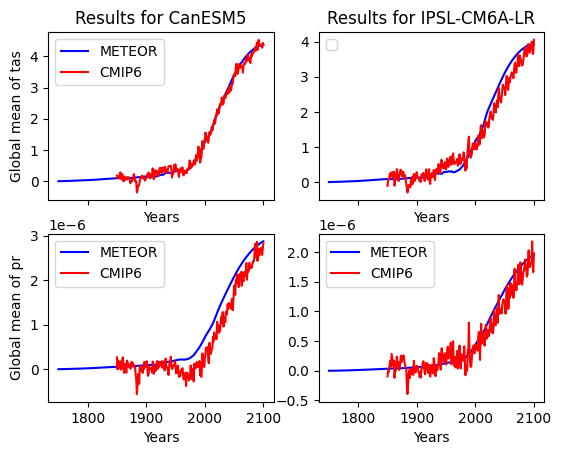

In [28]:
fig, axs = plt.subplots(nrows=len(flds), ncols=len(models), sharex=True)

for i, model in enumerate(models):
    for j, fld in enumerate(flds):
        zero_val = np.mean(prpatt.global_mean(data_pi[i][fld]).values)
        print(zero_val)
        hist_time = prpatt.global_mean(data_hist[i][fld]).values[0]
        #print(f"Variable: {fld} and model {model}: {hist_time}")
        axs[j,i].plot(years_total, prpatt.global_mean(pattern_ssp[i][fld]).values, color="blue", label="METEOR")
        print(model)
        axs[j,i].plot(years_hist[:len(hist_time)], hist_time - zero_val, color="red", label="CMIP6")
        axs[j,i].plot(years_ssp, prpatt.global_mean(data_ssp[i][fld]).values[0] - zero_val, color="red")
        #axs[j,i].set_xlim(left=1850, right=2100)
        axs[j,i].set_xlabel("Years")
        if j == 0:
            axs[j,i].set_title(f"Results for {model}")
        if i == 0:
            axs[j,i].set_ylabel(f"Global mean of {fld}")
        axs[i,j].legend()
    #print(model_basic_pattern.exp_forc_dict)

In [29]:
hist_time - zero_val

array([-9.55114566e-08, -5.88574177e-09, -1.99001370e-08,  4.14303842e-08,
        1.25350691e-07,  1.69341732e-07,  7.13852829e-08,  2.83385366e-07,
        2.16900177e-07,  1.57654558e-07,  7.56048496e-08,  1.70450076e-07,
       -1.18882975e-07,  6.86484274e-09, -4.66691294e-09,  1.43230625e-07,
        2.37293041e-07,  8.94326046e-08,  1.46985582e-07,  7.41201861e-08,
        1.28284028e-08,  6.34632313e-08,  1.80810774e-07,  2.53071457e-07,
        1.45168523e-07,  2.24389158e-07,  1.97383106e-07,  2.59960257e-07,
        2.29575107e-07,  1.32937362e-07,  1.06354472e-07,  5.20870785e-08,
        3.44531590e-08, -2.44620405e-07, -3.92694964e-07, -2.54203684e-07,
       -6.07990894e-08,  7.92270582e-09, -1.23860953e-07, -5.36112053e-08,
        2.48722858e-08, -5.77924944e-08,  3.61065966e-08,  4.52563745e-08,
       -6.86915452e-08,  1.66679852e-07,  5.30223234e-08,  3.21955196e-08,
       -2.93207900e-08,  5.20674739e-08,  8.20674781e-08,  7.62161242e-08,
        2.99551513e-08, -

In [30]:
tmp_hist[1].mean('lat').mean('lon')

<xarray.DataArray 'pr' (ens: 1, year: 165)> Size: 1kB
array([[2.79489374e-05, 2.80891395e-05, 2.80537672e-05, 2.81372505e-05,
        2.82154783e-05, 2.82118296e-05, 2.82628499e-05, 2.82795086e-05,
        2.83187809e-05, 2.82549859e-05, 2.80991337e-05, 2.83166722e-05,
        2.79169406e-05, 2.80697282e-05, 2.80690895e-05, 2.81953292e-05,
        2.82310367e-05, 2.81598372e-05, 2.81388950e-05, 2.81282754e-05,
        2.80791497e-05, 2.81628533e-05, 2.82927364e-05, 2.82803309e-05,
        2.82539447e-05, 2.82366949e-05, 2.81947831e-05, 2.82979538e-05,
        2.82836344e-05, 2.82088005e-05, 2.81643853e-05, 2.81034245e-05,
        2.80561185e-05, 2.78067672e-05, 2.77288507e-05, 2.77427303e-05,
        2.79401663e-05, 2.80803116e-05, 2.79272553e-05, 2.79528262e-05,
        2.80699329e-05, 2.79479929e-05, 2.81135322e-05, 2.81277656e-05,
        2.79919460e-05, 2.81356910e-05, 2.81636550e-05, 2.80854368e-05,
        2.80744852e-05, 2.81003940e-05, 2.81714489e-05, 2.80965008e-05,
        2.81726239e-05, 2.79730847e-05, 2.80248177e-05, 2.79499455e-05,
        2.80645331e-05, 2.79440441e-05, 2.81102169e-05, 2.82068442e-05,
        2.81333905e-05, 2.81567048e-05, 2.81367082e-05, 2.80097698e-05,
        2.80303260e-05, 2.80948225e-05, 2.81640525e-05, 2.81882421e-05,
        2.82029065e-05, 2.80270630e-05, 2.80680154e-05, 2.81624449e-05,
        2.80061377e-05, 2.79203298e-05, 2.81182794e-05, 2.81681634e-05,
        2.81214276e-05, 2.80063771e-05, 2.80885829e-05, 2.82065570e-05,
...
        2.82472750e-05, 2.81766333e-05, 2.81148204e-05, 2.80574266e-05,
        2.83945703e-05, 2.84949090e-05, 2.83478542e-05, 2.83516200e-05,
        2.82406818e-05, 2.83753947e-05, 2.83276335e-05, 2.83900061e-05,
        2.81805468e-05, 2.82544877e-05, 2.83877431e-05, 2.85289319e-05,
        2.83331554e-05, 2.84250246e-05, 2.83892375e-05, 2.83916673e-05,
        2.85483311e-05, 2.82146440e-05, 2.83214088e-05, 2.83288316e-05,
        2.86077324e-05, 2.83381337e-05, 2.82953141e-05, 2.83384790e-05,
        2.82442977e-05, 2.82961779e-05, 2.82688378e-05, 2.84331952e-05,
        2.81748640e-05, 2.81830024e-05, 2.83005367e-05, 2.85195316e-05,
        2.82765812e-05, 2.82016650e-05, 2.83797706e-05, 2.82936403e-05,
        2.83208030e-05, 2.83218263e-05, 2.84284653e-05, 2.84607988e-05,
        2.83549257e-05, 2.80671843e-05, 2.81551265e-05, 2.81183323e-05,
        2.82350069e-05, 2.84506580e-05, 2.85371848e-05, 2.88566131e-05,
        2.85321569e-05, 2.83928282e-05, 2.83425160e-05, 2.83090960e-05,
        2.83880427e-05, 2.86568610e-05, 2.85712436e-05, 2.86009661e-05,
        2.84746795e-05, 2.84209190e-05, 2.85725103e-05, 2.84823735e-05,
        2.84817681e-05, 2.85927086e-05, 2.84727284e-05, 2.87444011e-05,
        2.88292441e-05, 2.87069687e-05, 2.84516456e-05, 2.87285801e-05,
        2.89725072e-05, 2.86659953e-05, 2.88816644e-05, 2.87089312e-05,
        2.87370683e-05]])
Coordinates:
  * ens      (ens) int64 8B 1
  * year     (year) int64 1kB 0 1 2 3 4 5 6 7 ... 158 159 160 161 162 163 164